In [1]:
from dataclasses import asdict
from itertools import combinations

import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
if "I__hvgs" not in ds.RNA.feats.columns:
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
    )
ds.run_normalization(feat_key="hvgs")
pca = ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
)

Downloading bucket files: 48357614 / 48357614 complete

Downloading bytes: 48357614 / 48357614 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

...

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 150 / 150 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='ab132cece6ac...')

In [2]:
leiden_candidates = {
    0.3: "leiden_r03",
    0.5: "leiden_r05",
    0.8: "leiden_r08",
}
for resolution, label in leiden_candidates.items():
    ds.run_leiden_clustering(
        resolution=resolution,
        label=label,
    )
chosen_key = "RNA_leiden_r05"

In [3]:
cluster_sizes = pd.DataFrame(
    {
        label: pd.Series(
            ds.cells.fetch(f"RNA_{label}", key="I")
        ).value_counts()
        for label in leiden_candidates.values()
    }
).fillna(0).astype(int)
cluster_sizes

,leiden_r03,leiden_r05,leiden_r08
1,1312,1261,690
2,921,699,618
3,724,670,617
4,317,318,609
5,252,299,318
6,246,252,309
7,141,246,252
8,15,143,246
9,12,25,143
10,0,15,77


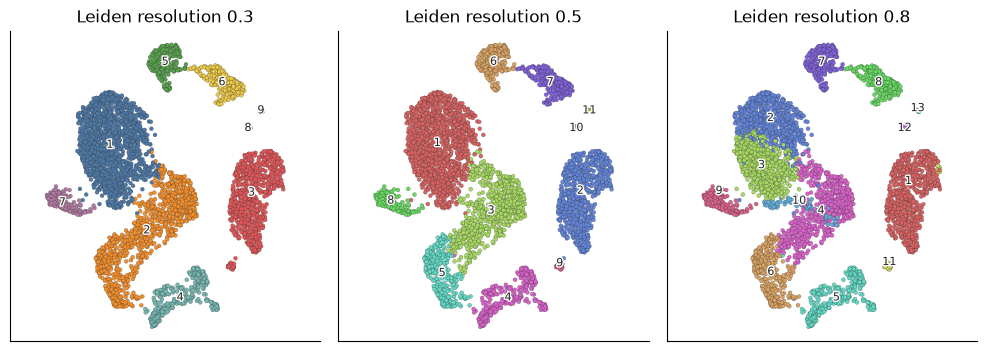

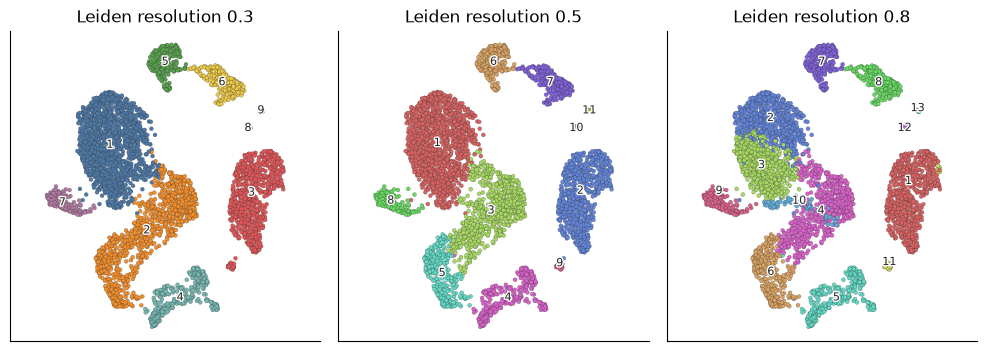

In [4]:
leiden_comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[f"RNA_{label}" for label in leiden_candidates.values()],
    n_columns=3,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, resolution in zip(
    leiden_comparison.axes.values(), leiden_candidates, strict=True
):
    axis.set_title(f"Leiden resolution {resolution}")
leiden_comparison.figure

In [5]:
chosen_sizes = (
    pd.Series(ds.cells.fetch(chosen_key, key="I"))
    .value_counts()
    .sort_values()
)
chosen_sizes

11      12
10      15
9       25
8      143
7      246
6      252
5      299
4      318
3      670
2      699
1     1261
Name: count, dtype: int64

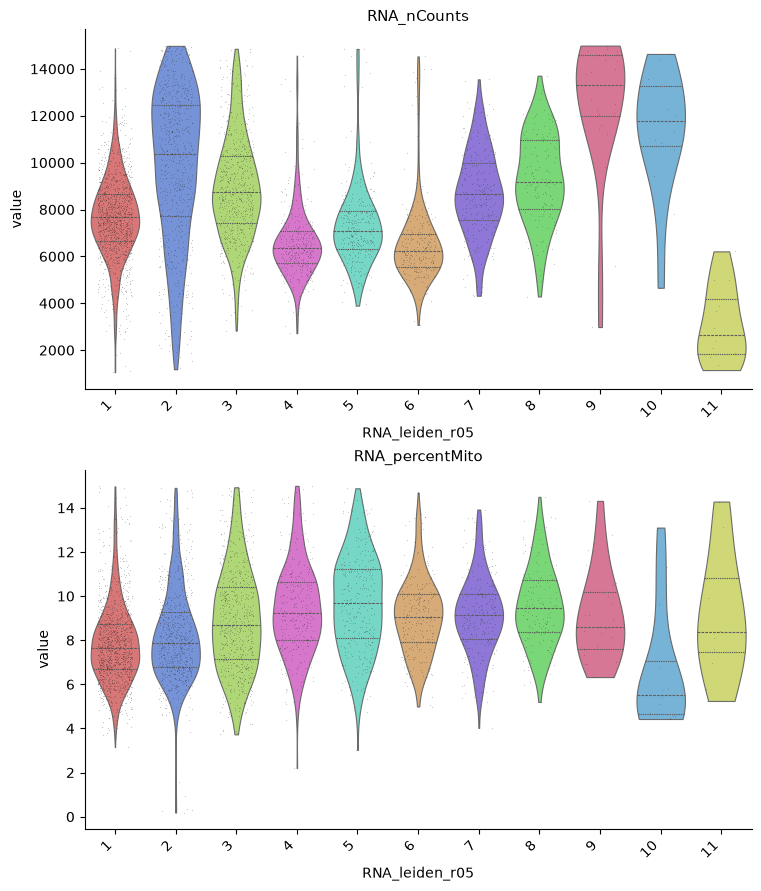

In [6]:
ds.plots.distribution(
    keys=["RNA_nCounts", "RNA_percentMito"],
    group_by=chosen_key,
    kind="violin",
)

In [7]:
agreement_rows = []
for first, second in combinations(leiden_candidates.values(), 2):
    columns = [f"RNA_{first}", f"RNA_{second}"]
    agreement_rows.append(
        {
            "comparison": f"{first} vs {second}",
            "ARI": ds.metric_label_concordance(
                columns,
                metric="ari",
            ),
            "NMI": ds.metric_label_concordance(
                columns,
                metric="nmi",
            ),
        }
    )
pd.DataFrame(agreement_rows)

,comparison,ARI,NMI
0,leiden_r03 vs leiden_r05,0.879360,0.922347
1,leiden_r03 vs leiden_r08,0.664990,0.848427
2,leiden_r05 vs leiden_r08,0.769839,0.907833


In [8]:
silhouette_rows = []
for label in leiden_candidates.values():
    scores = ds.metric_graph_silhouette(res_label=label)
    silhouette_rows.append(
        {
            "partition": label,
            "mean graph silhouette": float(np.nanmean(scores)),
            "minimum graph silhouette": float(np.nanmin(scores)),
        }
    )
pd.DataFrame(silhouette_rows)

Calculating silhouette scores: 9 / 9 complete

Calculating silhouette scores: 11 / 11 complete

Calculating silhouette scores: 13 / 13 complete

,partition,mean graph silhouette,minimum graph silhouette
0,leiden_r03,0.470768,0.119297
1,leiden_r05,0.478833,0.310076
2,leiden_r08,0.423936,0.133667


In [9]:
graph_scores = ds.metric_graph_silhouette(res_label="leiden_r05")
clusters_all = ds.cells.fetch_all(chosen_key)
active_mask = ds.cells.fetch_all("I").astype(bool)
active_labels = pd.Series(clusters_all[active_mask])
categories = pd.Categorical(active_labels).categories
per_cluster_silhouette = pd.DataFrame(
    {
        "cluster": list(categories),
        "graph_silhouette": graph_scores,
        "n_cells": active_labels.value_counts()
        .reindex(categories)
        .to_numpy(),
    }
)
per_cluster_silhouette

Calculating silhouette scores: 11 / 11 complete

,cluster,graph_silhouette,n_cells
0,1,0.432421,1261
1,2,0.575145,699
2,3,0.384859,670
3,4,0.310076,318
4,5,0.346412,299
5,6,0.356379,252
6,7,0.489676,246
7,8,0.386511,143
8,9,0.585081,25
9,10,0.776096,15


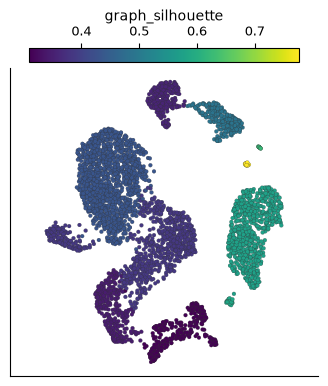

In [10]:
score_map = dict(zip(categories, graph_scores, strict=True))
mapped_silhouette = np.full(len(clusters_all), np.nan, dtype=float)
mapped_silhouette[active_mask] = (
    active_labels.map(score_map).to_numpy(dtype=float)
)
ds.cells.insert(
    "graph_silhouette",
    mapped_silhouette,
    overwrite=True,
)
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="graph_silhouette",
)

In [11]:
separability = ds.metric_cluster_separability(
    pca,
    cluster_columns=[
        f"RNA_{label}" for label in leiden_candidates.values()
    ],
)
separability.clustering_scores

,clustering,n_sampled_cells,n_clusters,macro_f1_mean,macro_f1_standard_error,weighted_f1_mean,silhouette_score,status,status_reason
0,RNA_leiden_r03,3940,9,0.975829,0.005696,0.982139,0.366468,scored,None
1,RNA_leiden_r05,3940,11,0.957099,0.011294,0.979899,0.345002,scored,None
2,RNA_leiden_r08,3940,13,0.920989,0.008221,0.944960,0.278357,scored,None


In [12]:
separability.cluster_scores.query(
    "clustering == @chosen_key"
).sort_values("f1_score")

,clustering,cluster_label,n_sampled_cells,f1_score
19,RNA_leiden_r05,11,12,0.769231
17,RNA_leiden_r05,9,25,0.909091
13,RNA_leiden_r05,5,299,0.955075
16,RNA_leiden_r05,3,670,0.960784
14,RNA_leiden_r05,8,143,0.969283
11,RNA_leiden_r05,1,1261,0.983711
12,RNA_leiden_r05,4,318,0.992175
9,RNA_leiden_r05,2,699,0.993558
10,RNA_leiden_r05,7,246,0.993915
15,RNA_leiden_r05,6,252,0.994036


In [13]:
separability.confusion.query("clustering == @chosen_key")

,clustering,true_cluster,predicted_cluster,n_cells,fraction_of_true_cluster
81,RNA_leiden_r05,2,2,694,0.992847
82,RNA_leiden_r05,2,7,1,0.001431
83,RNA_leiden_r05,2,1,0,0.000000
84,RNA_leiden_r05,2,4,0,0.000000
85,RNA_leiden_r05,2,5,0,0.000000
...,...,...,...,...,...
197,RNA_leiden_r05,11,6,0,0.000000
198,RNA_leiden_r05,11,3,0,0.000000
199,RNA_leiden_r05,11,9,1,0.083333
200,RNA_leiden_r05,11,10,0,0.000000


In [14]:
ds.calc_membership_strength(
    "RNA",
    "I",
    "hvgs",
    chosen_key,
)
membership_key = "RNA_I_cluster_membership_strength"

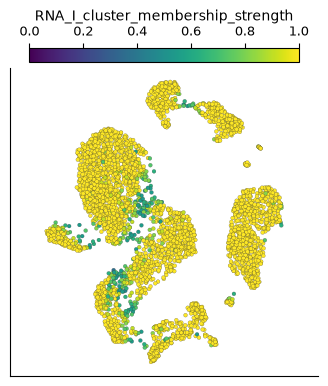

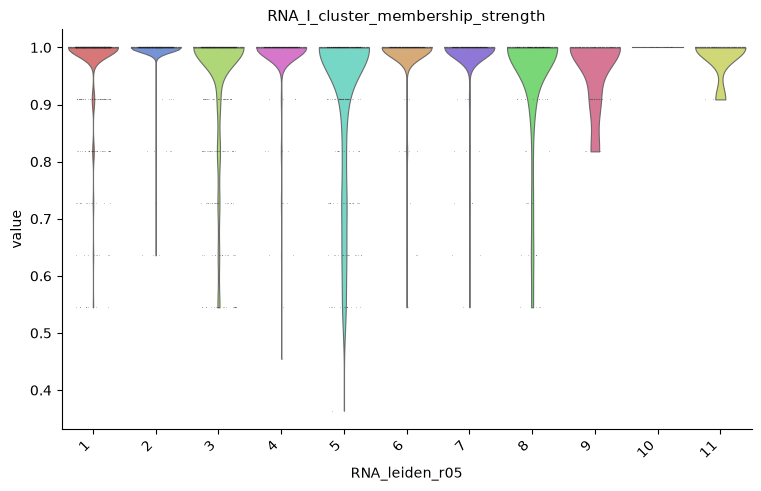

In [15]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=membership_key,
)
ds.plots.distribution(
    keys=membership_key,
    group_by=chosen_key,
    kind="violin",
)

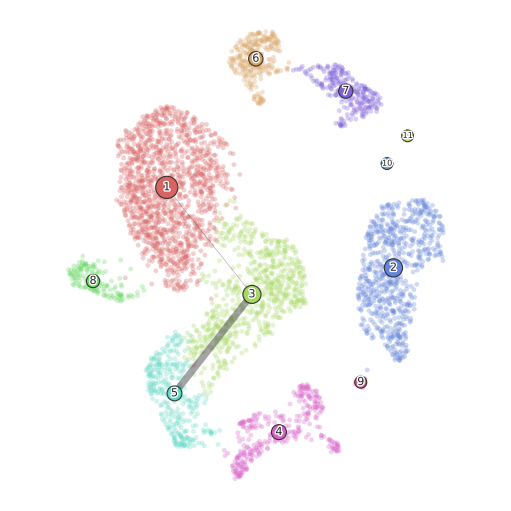

In [16]:
ds.plots.cluster_connectivity(
    group_by=chosen_key,
    layout_key="RNA_UMAP",
    from_assay="RNA",
    feat_key="hvgs",
    show_cells=True,
)

In [17]:
paris_auto = ds.run_paris_clustering(
    n_clusters="auto",
    label="paris_auto",
)
pd.DataFrame(
    [asdict(item) for item in paris_auto.diagnostics]
)[
    [
        "label",
        "size",
        "persistence",
        "decision_margin",
        "forced",
    ]
]

,label,size,persistence,decision_margin,forced
0,1,722,316.029101,0.215854,False
1,2,248,149.564160,0.490342,False
2,3,1231,395.579626,0.126983,False
3,4,317,144.429144,0.139588,False
4,5,296,87.891821,0.067428,False
5,6,112,57.106690,0.480737,False
6,7,252,125.432201,0.300492,False
7,8,566,110.028259,NaN,False
8,9,169,40.337659,0.023954,False
9,10,15,NaN,NaN,True


In [18]:
paris_fixed = ds.run_paris_clustering(
    n_clusters=paris_auto.n_clusters,
    label="paris_fixed",
)
ds.metric_label_concordance(
    [paris_auto.label_key, paris_fixed.label_key],
    metric="ari",
)

0.8039303546722508

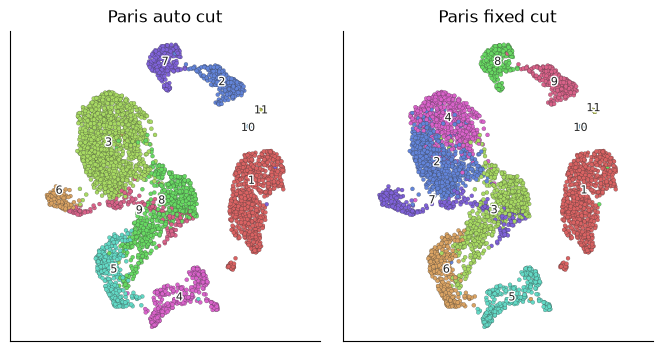

In [19]:
paris_comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[paris_auto.label_key, paris_fixed.label_key],
    n_columns=2,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, title in zip(
    paris_comparison.axes.values(),
    ["Paris auto cut", "Paris fixed cut"],
    strict=True,
):
    axis.set_title(title)
paris_comparison.figure

Constructing graph from dendrogram: 3939 / 3939 complete

Identifying the top node for cluster: 1 / 1 complete

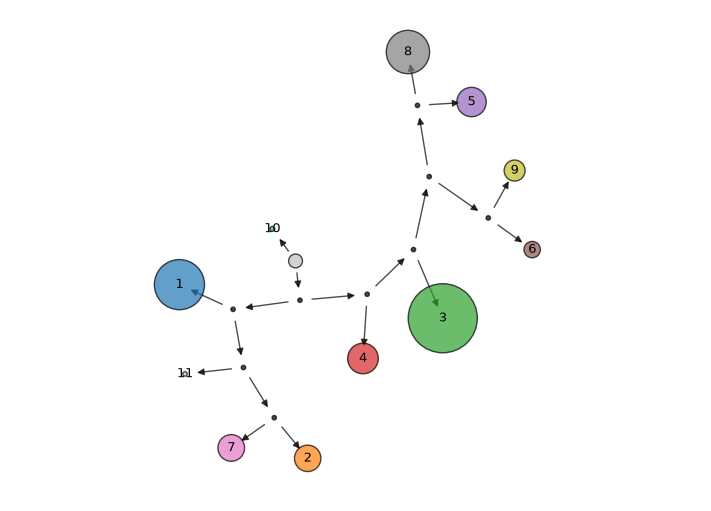

In [20]:
ds.plots.cluster_tree(
    cluster_key=paris_auto.label_key,
    width=1.7,
    fontsize=9,
    figsize=(7, 5),
)

ARI: 0.8868770782142551


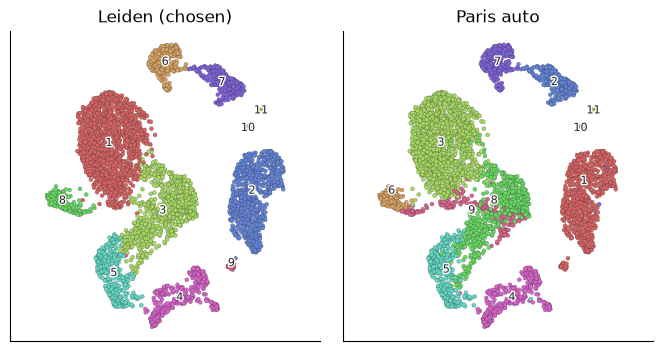

In [21]:
leiden_paris = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[chosen_key, paris_auto.label_key],
    n_columns=2,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, title in zip(
    leiden_paris.axes.values(),
    ["Leiden (chosen)", "Paris auto"],
    strict=True,
):
    axis.set_title(title)
print(
    "ARI:",
    ds.metric_label_concordance(
        [chosen_key, paris_auto.label_key],
        metric="ari",
    ),
)
leiden_paris.figure

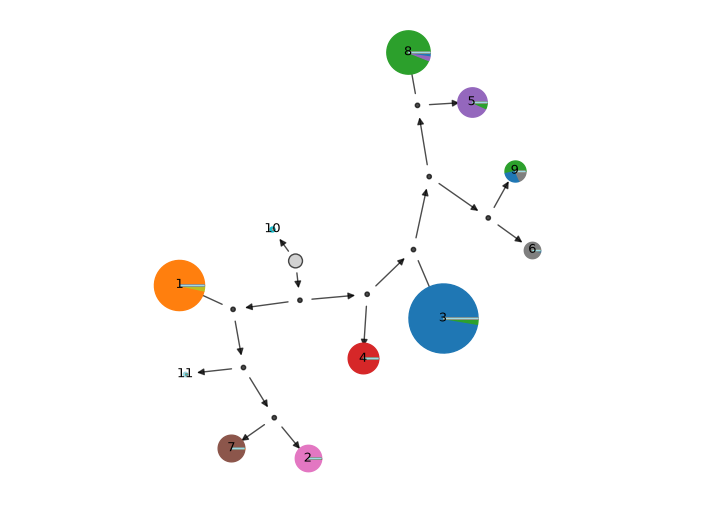

In [22]:
ds.plots.cluster_tree(
    cluster_key=paris_auto.label_key,
    fill_by_value=chosen_key,
    width=1.7,
    fontsize=9,
    figsize=(7, 5),
)

In [23]:
ds.run_marker_search(group_key=chosen_key)
largest_group = chosen_sizes.index[-1]
smallest_group = chosen_sizes.index[0]
markers = ds.get_markers(
    group_key=chosen_key,
    group_id=largest_group,
)
print(f"Largest group: {largest_group} (n={int(chosen_sizes.loc[largest_group])})")
markers[
    [
        "feature_name",
        "score",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(10)

Finding markers: 1 / 1 complete

Largest group: 1 (n=1261)


,feature_name,score,auc,p_value,p_value_adjusted
0,ADTRP,0.65392,0.60948,2.476793e-109,1.832955e-107
1,TSHZ2,0.57190,0.63942,4.094205e-123,3.677832e-121
2,CHRM3-AS2,0.50922,0.66602,6.665595e-152,8.278669e-150
3,TCEA3,0.50281,0.59004,7.034657e-76,2.737766e-74
4,FHIT,0.48549,0.77698,9.127469e-289,4.345588e-286
5,CMTM8,0.48413,0.62095,8.656853e-89,4.719307e-87
6,EPHX2,0.44864,0.66482,2.346257e-142,2.577815e-140
7,MAN1C1,0.43633,0.62223,3.442119e-85,1.689477e-83
8,MAL,0.43398,0.77381,7.526286e-246,2.336912e-243
9,NOG,0.41067,0.61907,2.165293e-120,1.874357e-118


In [24]:
small_markers = ds.get_markers(
    group_key=chosen_key,
    group_id=smallest_group,
)
print(
    f"Smallest group: {smallest_group} "
    f"(n={int(chosen_sizes.loc[smallest_group])})"
)
small_markers[
    [
        "feature_name",
        "score",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(10)

Smallest group: 11 (n=12)


,feature_name,score,auc,p_value,p_value_adjusted
0,F13A1,0.82249,0.99998,2.737010e-45,5.076975e-43
1,ACRBP,0.81844,0.95774,2.061862e-132,6.848740e-130
2,DMTN,0.81398,0.95618,8.963924e-45,1.620655e-42
3,PRKAR2B,0.80990,1.00000,2.000594e-184,8.164140e-182
4,PTGS1,0.80981,0.99998,2.044860e-73,5.035643e-71
5,CD9,0.80885,0.99992,8.068113e-78,2.095216e-75
6,AP003068.2,0.80540,0.95765,1.075183e-118,3.267414e-116
7,HIST1H2BJ,0.80462,0.87170,5.732431e-54,1.169662e-51
8,CLU,0.79982,1.00000,2.078877e-194,8.997760e-192
9,HIST1H3H,0.79924,0.95730,1.836591e-99,5.353477e-97


Aggregating marker values per group: 1 / 1 complete

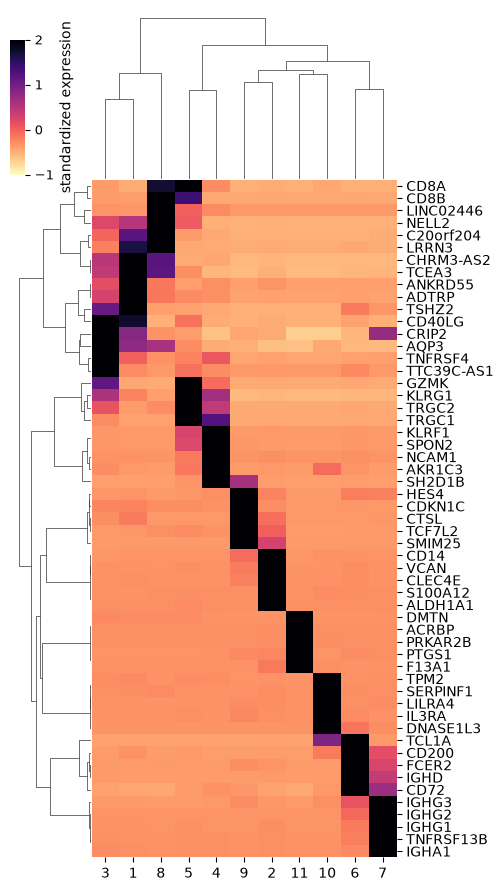

In [25]:
ds.plots.marker_heatmap(
    group_key=chosen_key,
    topn=5,
    figsize=(5, 9),
)

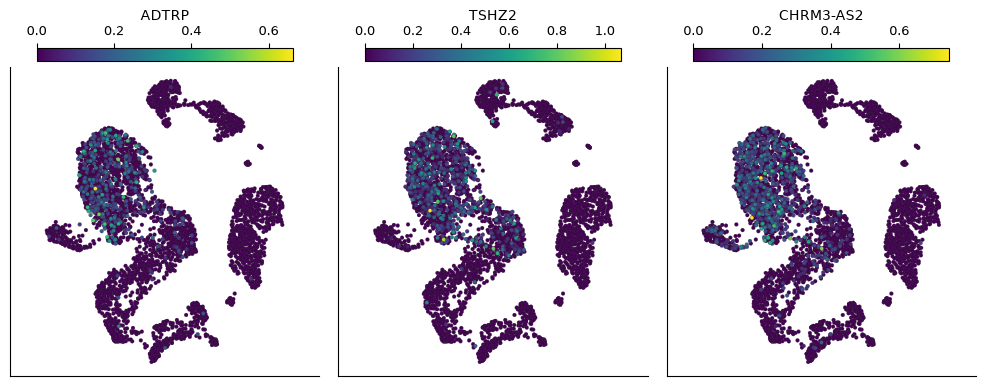

In [26]:
top_genes = markers["feature_name"].astype(str).head(3).tolist()
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=top_genes,
    n_columns=3,
    sort_values=True,
)

Focus cluster: 1
Focus cells: 1261


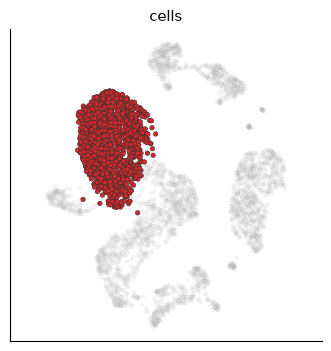

In [27]:
clusters = ds.cells.fetch_all(chosen_key)
active = ds.cells.fetch_all("I").astype(bool)
focus = pd.Series(clusters[active]).value_counts().index[0]
ds.cells.insert(
    "focus_cells",
    active & (clusters == focus),
    overwrite=True,
)
print(f"Focus cluster: {focus}")
print(f"Focus cells: {int(ds.cells.fetch_all('focus_cells').sum())}")
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=None,
    default_color="#bdbdbd",
    point_alpha=0.4,
    highlight=splt.Highlight(
        by="focus_cells",
        groups=(True,),
        color="#d62728",
        dim_alpha=0.12,
        size_multiplier=1.35,
        halo_width=0.4,
    ),
)

In [28]:
ds.mark_hvgs(
    cell_key="focus_cells",
    min_cells=10,
    top_n=500,
    show_plot=False,
)
ds.run_normalization(
    cell_key="focus_cells",
    feat_key="hvgs",
)
ds.run_pca(dims=15)
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(
    cell_key="focus_cells",
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label="UMAP",
)
ds.run_leiden_clustering(
    cell_key="focus_cells",
    resolution=0.4,
    label="leiden_cluster",
)
pd.Series(
    ds.cells.fetch("RNA_focus_cells_leiden_cluster", key="focus_cells")
).value_counts()

Calculating feature statistics: 15 / 15 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 100 / 100 complete

1    575
2    337
3    334
4     15
Name: count, dtype: int64

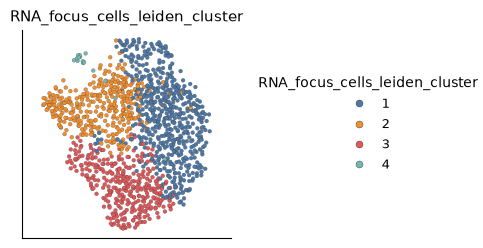

In [29]:
ds.plots.embedding(
    layout_key="RNA_focus_cells_UMAP",
    color_by="RNA_focus_cells_leiden_cluster",
    cell_key="focus_cells",
)